# Behavioural Early Warning & Intervention Intelligence System
### Early Detection of Student Burnout & Dropout Risk

This system predicts burnout risk, estimates dropout probability,
identifies behavioural triggers, and recommends targeted interventions.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix,
    r2_score,
    mean_squared_error
)
from sklearn.preprocessing import LabelEncoder

import shap

In [3]:
df = pd.read_csv("student_burnout_dataset.csv")

print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
df.head()

Dataset Shape: (4000, 10)

Missing Values:
 student_id                   0
lms_logins_weekly            0
login_trend_slope            0
avg_assignment_delay_days    0
attendance_percent           0
attendance_trend             0
sentiment_score              0
study_session_variability    0
burnout_risk_level           0
dropout_probability          0
dtype: int64


,student_id,lms_logins_weekly,login_trend_slope,avg_assignment_delay_days,attendance_percent,attendance_trend,sentiment_score,study_session_variability,burnout_risk_level,dropout_probability
0,1,14,-0.691,0.08,93.25,-1.680,-0.214,0.373,Medium,0.292
1,2,11,-0.025,1.58,70.28,-1.022,0.358,0.346,Low,0.201
2,3,15,0.014,6.46,60.57,-7.270,0.333,0.348,Low,0.262
3,4,18,0.378,1.27,100.00,4.184,-0.140,0.369,Low,0.174
4,5,11,-1.093,2.45,100.00,1.101,-0.914,0.304,High,0.532


In [4]:
le = LabelEncoder()
df["burnout_encoded"] = le.fit_transform(df["burnout_risk_level"])

df["burnout_encoded"].value_counts()

,count
burnout_encoded,
1,2486
2,1393
0,121


In [5]:
# Academic Stress Index
df["academic_stress_index"] = (
    0.6 * (df["avg_assignment_delay_days"] / 10) +
    0.4 * ((100 - df["attendance_percent"]) / 100)
)

# Engagement Volatility Score
df["engagement_volatility_score"] = (
    np.abs(df["login_trend_slope"]) / df["login_trend_slope"].abs().max()
)

# Emotional Distress Score
df["emotional_distress_score"] = np.maximum(0, -df["sentiment_score"])

# Burnout Composite Score (0–100)
df["burnout_composite_score"] = (
    0.25 * (25 - df["lms_logins_weekly"]) / 25 +
    0.20 * df["academic_stress_index"] +
    0.20 * df["engagement_volatility_score"] +
    0.20 * df["emotional_distress_score"] +
    0.15 * df["study_session_variability"]
)

df["burnout_composite_score"] = np.round(
    100 * df["burnout_composite_score"], 2
)

In [6]:
features = [
    "lms_logins_weekly",
    "login_trend_slope",
    "avg_assignment_delay_days",
    "attendance_percent",
    "attendance_trend",
    "sentiment_score",
    "study_session_variability",
    "academic_stress_index",
    "engagement_volatility_score",
    "emotional_distress_score"
]

X = df[features]
y = df["burnout_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.955

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.79      0.86        24
           1       0.96      0.98      0.97       497
           2       0.94      0.93      0.94       279

    accuracy                           0.95       800
   macro avg       0.95      0.90      0.92       800
weighted avg       0.95      0.95      0.95       800



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [7]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Burnout Classification Accuracy:",
      round(accuracy_score(y_test, y_pred), 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Burnout Classification Accuracy: 0.9513

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.75      0.86        24
           1       0.96      0.98      0.97       497
           2       0.93      0.92      0.93       279

    accuracy                           0.95       800
   macro avg       0.96      0.88      0.92       800
weighted avg       0.95      0.95      0.95       800



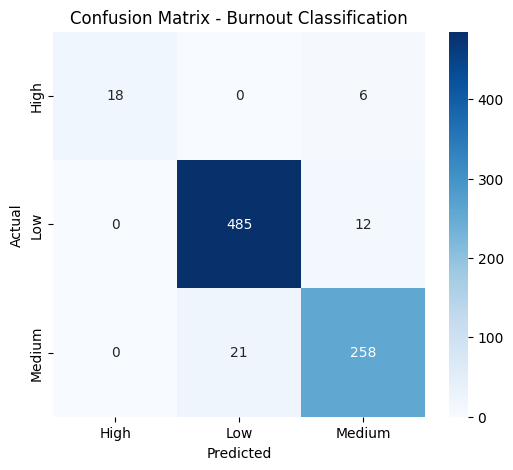

In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")

plt.title("Confusion Matrix - Burnout Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

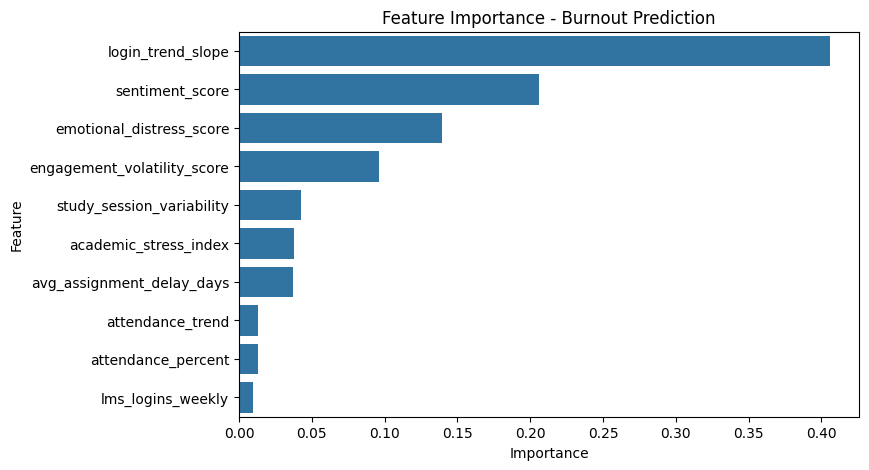

,Feature,Importance
1,login_trend_slope,0.405612
5,sentiment_score,0.205775
9,emotional_distress_score,0.139494
8,engagement_volatility_score,0.096438
6,study_session_variability,0.042565


In [9]:
importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Feature Importance - Burnout Prediction")
plt.show()

importance_df.head()

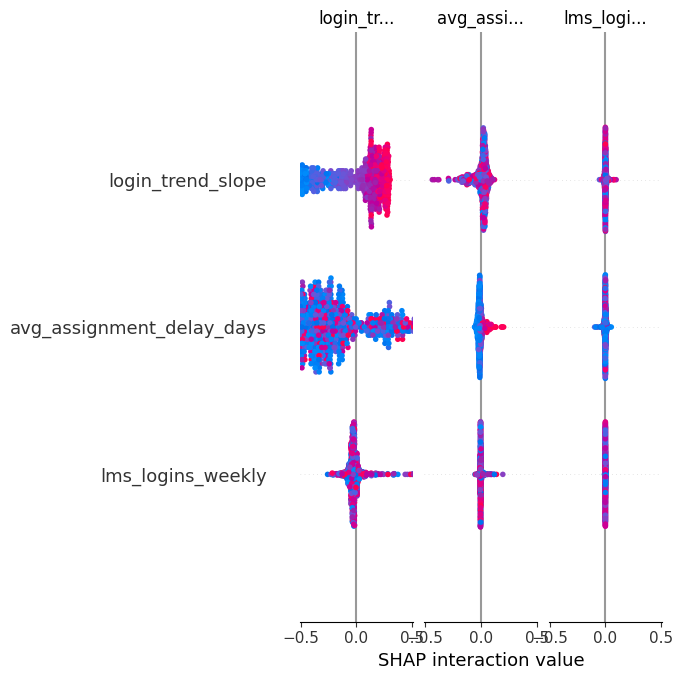

In [10]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [11]:
X_reg = df[features]
y_reg = df["dropout_probability"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

rf_reg = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_reg.fit(X_train_r, y_train_r)

y_pred_reg = rf_reg.predict(X_test_r)

print("Dropout R2 Score:",
      round(r2_score(y_test_r, y_pred_reg), 4))

print("Dropout RMSE:",
      round(np.sqrt(mean_squared_error(y_test_r, y_pred_reg)), 4))

Dropout R2 Score: 0.9825
Dropout RMSE: 0.014


In [12]:
df["system_risk_score"] = df["burnout_composite_score"]

def risk_category(score):
    if score < 40:
        return "Low"
    elif score < 70:
        return "Medium"
    else:
        return "High"

df["system_risk_category"] = df["system_risk_score"].apply(risk_category)

In [13]:
def top_3_triggers(row):
    risk_factors = {
        "Low Attendance": (100 - row["attendance_percent"]),
        "High Assignment Delay": row["avg_assignment_delay_days"],
        "Negative Sentiment": -row["sentiment_score"] if row["sentiment_score"] < 0 else 0,
        "Low LMS Engagement": (25 - row["lms_logins_weekly"]),
        "High Study Instability": row["study_session_variability"] * 10
    }
    sorted_triggers = sorted(
        risk_factors.items(),
        key=lambda x: x[1],
        reverse=True
    )
    return [sorted_triggers[0][0],
            sorted_triggers[1][0],
            sorted_triggers[2][0]]

df["top_3_triggers"] = df.apply(top_3_triggers, axis=1)

In [14]:
def smart_intervention(row):
    if row["system_risk_category"] == "High":
        return "Immediate Advisor Meeting + Mental Health Support + Academic Load Review"
    elif row["system_risk_category"] == "Medium":
        return "Weekly Mentoring + Attendance Monitoring + Peer Study Group"
    else:
        return "Positive Reinforcement + Skill Development Workshops"

df["recommended_intervention"] = df.apply(smart_intervention, axis=1)

In [15]:
total_students = len(df)
high_risk_rate = round(
    (df["system_risk_category"] == "High").mean() * 100, 2
)

print("Total Students:", total_students)
print("High Risk Percentage:", high_risk_rate, "%")

Total Students: 4000
High Risk Percentage: 0.0 %


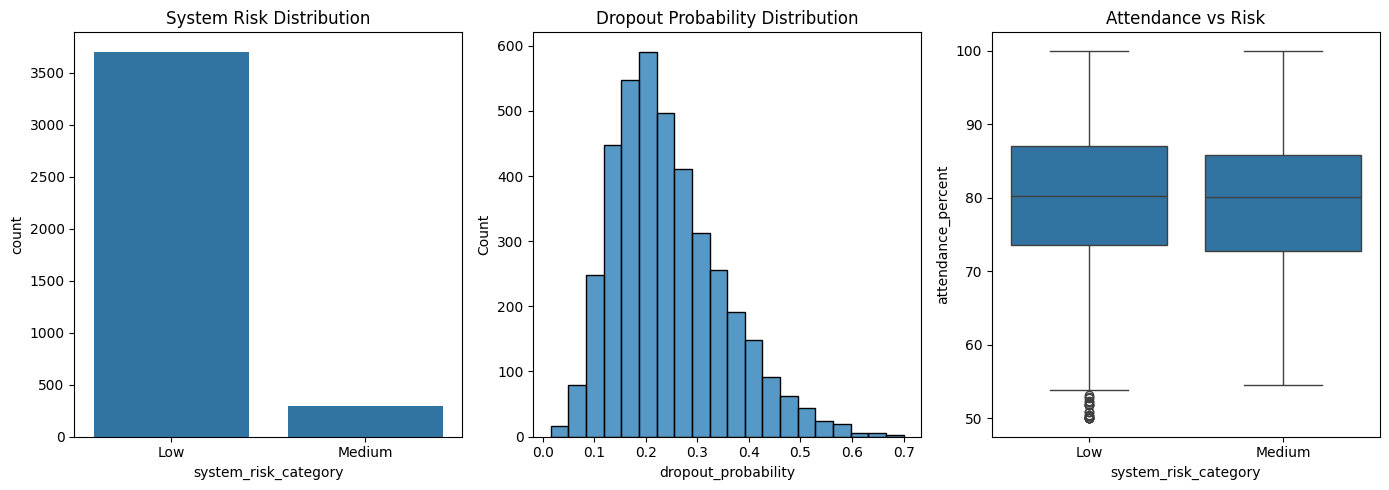

In [16]:
plt.figure(figsize=(14,5))

plt.subplot(1,3,1)
sns.countplot(x="system_risk_category", data=df)
plt.title("System Risk Distribution")

plt.subplot(1,3,2)
sns.histplot(df["dropout_probability"], bins=20)
plt.title("Dropout Probability Distribution")

plt.subplot(1,3,3)
sns.boxplot(x="system_risk_category", y="attendance_percent", data=df)
plt.title("Attendance vs Risk")

plt.tight_layout()
plt.show()

In [17]:
df[[
    "student_id",
    "system_risk_score",
    "system_risk_category",
    "top_3_triggers",
    "recommended_intervention"
]].head()

,student_id,system_risk_score,system_risk_category,top_3_triggers,recommended_intervention
0,1,26.19,Low,"[Low LMS Engagement, Low Attendance, High Stud...",Positive Reinforcement + Skill Development Wor...
1,2,23.63,Low,"[Low Attendance, Low LMS Engagement, High Stud...",Positive Reinforcement + Skill Development Wor...
2,3,26.22,Low,"[Low Attendance, Low LMS Engagement, High Assi...",Positive Reinforcement + Skill Development Wor...
3,4,19.42,Low,"[Low LMS Engagement, High Study Instability, H...",Positive Reinforcement + Skill Development Wor...
4,5,47.19,Medium,"[Low LMS Engagement, High Study Instability, H...",Weekly Mentoring + Attendance Monitoring + Pee...


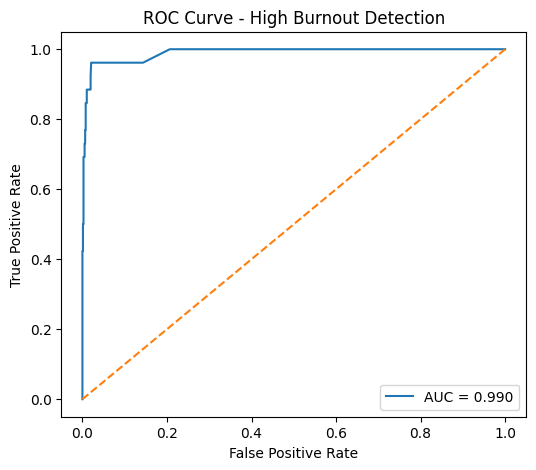

AUC Score: 0.9897


In [18]:
from sklearn.metrics import roc_curve, auc

# Binary target (High risk vs others)
y_binary = (df["burnout_risk_level"] == "High").astype(int)

X_bin = df[features]
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_bin, y_binary, test_size=0.2, random_state=42
)

rf_binary = RandomForestClassifier(n_estimators=200, random_state=42)
rf_binary.fit(X_train_b, y_train_b)

y_prob = rf_binary.predict_proba(X_test_b)[:,1]

fpr, tpr, thresholds = roc_curve(y_test_b, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - High Burnout Detection")
plt.legend()
plt.show()

print("AUC Score:", round(roc_auc, 4))

In [22]:
# Percentile-based dynamic risk categorization
low_threshold = df["system_risk_score"].quantile(0.4)
high_threshold = df["system_risk_score"].quantile(0.75)

def risk_category(score):
    if score < low_threshold:
        return "Low"
    elif score < high_threshold:
        return "Medium"
    else:
        return "High"

df["system_risk_category"] = df["system_risk_score"].apply(risk_category)

print("Low Threshold:", round(low_threshold,2))
print("High Threshold:", round(high_threshold,2))
df["system_risk_category"].value_counts()

Low Threshold: 25.96
High Threshold: 33.12


,count
system_risk_category,
Low,1598
Medium,1402
High,1000


In [23]:
warning_threshold = df["system_risk_score"].quantile(0.8)

df["early_warning_flag"] = np.where(
    (df["system_risk_score"] >= warning_threshold) &
    (df["attendance_percent"] < df["attendance_percent"].median()),
    1, 0
)

warning_rate = round(df["early_warning_flag"].mean()*100,2)

print("Early Warning Threshold:", round(warning_threshold,2))
print("Students Triggering Early Warning System:", warning_rate, "%")

Early Warning Threshold: 34.54
Students Triggering Early Warning System: 10.75 %


In [24]:
summary_table = df.groupby("system_risk_category").agg({
    "attendance_percent": "mean",
    "avg_assignment_delay_days": "mean",
    "sentiment_score": "mean",
    "dropout_probability": "mean"
}).round(2)

summary_table

,attendance_percent,avg_assignment_delay_days,sentiment_score,dropout_probability
system_risk_category,,,,
High,79.17,3.74,-0.12,0.34
Low,81.09,1.66,0.35,0.19
Medium,79.69,2.52,0.22,0.24
